$$\textbf{Project 2-McCall Search Model}$$

---
Name: Amirreza "Farnam" Taheri

Institute: Tehran Institute for Advanced Studies - Department of Economics

Student ID: 4021300198003

Date: 2024-06-05

Instructor: Prof. Hosein Joshaghani

---

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def triangular_distribution(mu, r, size=1000, seed=None):
    """
    Generate samples from a triangular distribution.

    Parameters:
        mu (float): Mean of the distribution.
        r (float): Half of the width of the distribution.
        size (int): Number of samples to generate.
        seed (int): Seed for random number generation.

    Returns:
        numpy.ndarray: Array of samples from the triangular distribution.
    """
    np.random.seed(seed)  # Set the seed for reproducibility
    return np.random.triangular(mu - r, mu, mu + r, size)

def wage_distribution(samples, grid_size, seed=None):
    """
    Create a wage distribution from generated samples.

    Parameters:
        samples (numpy.ndarray): Array of wage samples.
        grid_size (int): Number of grid points for the wage distribution.
        seed (int): Seed for random number generation.

    Returns:
        wgrid (numpy.ndarray): Array of wage values.
        prob_w (numpy.ndarray): Array of probabilities for each wage value.
        var (float): Variance of the wage distribution.
    """
    np.random.seed(seed)  # Set the seed for reproducibility
    wgrid = np.linspace(np.min(samples), np.max(samples), grid_size)
    prob_w, _ = np.histogram(samples, bins=grid_size, density=True)
    prob_w /= prob_w.sum()  # Normalize probabilities to sum to 1
    var = np.var(samples)   # Calculate the variance
    
    return wgrid, prob_w, var

def calculate_utility(wgrid, prob_w, p, beta, b, initial_guess, tol=1e-6, max_iter=1e4):
    """
    Calculate the utility function using value iteration.

    Parameters:
        wgrid (numpy.ndarray): Array of wage values.
        prob_w (numpy.ndarray): Array of probabilities for each wage value.
        p (float): Probability of receiving a job offer when unemployed.
        beta (float): Discount factor.
        b (float): Unemployment benefit.
        initial_guess (numpy.ndarray): Initial guess for the utility function.
        tol (float): Tolerance level for convergence.
        max_iter (int): Maximum number of iterations.

    Returns:
        U0 (numpy.ndarray): Final utility values for each wage.
        n_iter (int): Number of iterations until convergence.
        eps (float): Final error value.
    """
    U0 = initial_guess
    n_iter = 0
    eps = tol + 1

    # Value iteration loop
    while eps > tol and n_iter < max_iter:
        U1 = b + beta * np.maximum(
            p * (wgrid / (1 - beta)) + (1 - p) * np.dot(prob_w, U0),
            np.dot(prob_w, U0)
        )
        eps = np.max(np.abs(U1 - U0))  # Calculate the maximum difference
        U0 = np.copy(U1)  # Update utility values
        n_iter += 1

    return U0, n_iter, eps

# Set the seed for reproducibility
seed_value = 8

# Parameters for triangular distribution
mu = 7  # Mean of the distribution
r1 = 3  # Half of the width of the distribution for the first case
r2 = 5  # Half of the width of the distribution for the second case
size = 6666  # Number of samples to generate

# Parameters for wage grid
grid_size = 313  # Number of grid points for the wage distribution

# Parameters for utility calculation
p = 0.8  # Probability of receiving a job offer when unemployed
beta = 0.98  # Discount factor
b = 3  # Unemployment benefit

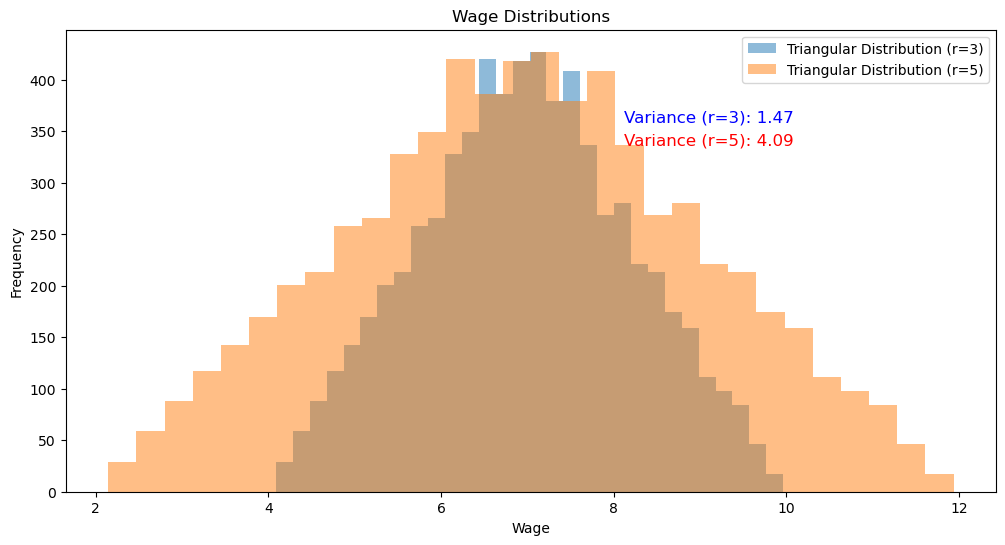

In [5]:
# Generate samples
dist1 = triangular_distribution(mu, r1, size, seed_value)
dist2 = triangular_distribution(mu, r2, size, seed_value)

# Generate wage distributions
wgrid_r3, prob_w_r3, var_r3 = wage_distribution(dist1, grid_size, seed_value)
wgrid_r5, prob_w_r5, var_r5 = wage_distribution(dist2, grid_size, seed_value)


# Plot wage distributions
plt.figure(figsize=(12, 6))
plt.hist(dist1, bins=30, alpha=0.5, label=f'Triangular Distribution (r={r1})')
plt.hist(dist2, bins=30, alpha=0.5, label=f'Triangular Distribution (r={r2})')
plt.legend()
plt.xlabel('Wage')
plt.ylabel('Frequency')
plt.title('Wage Distributions')
plt.text(0.6, 0.8, f'Variance (r={r1}): {var_r3:.2f}', transform=plt.gca().transAxes, fontsize=12, color='blue')
plt.text(0.6, 0.75, f'Variance (r={r2}): {var_r5:.2f}', transform=plt.gca().transAxes, fontsize=12, color='red')
plt.show()

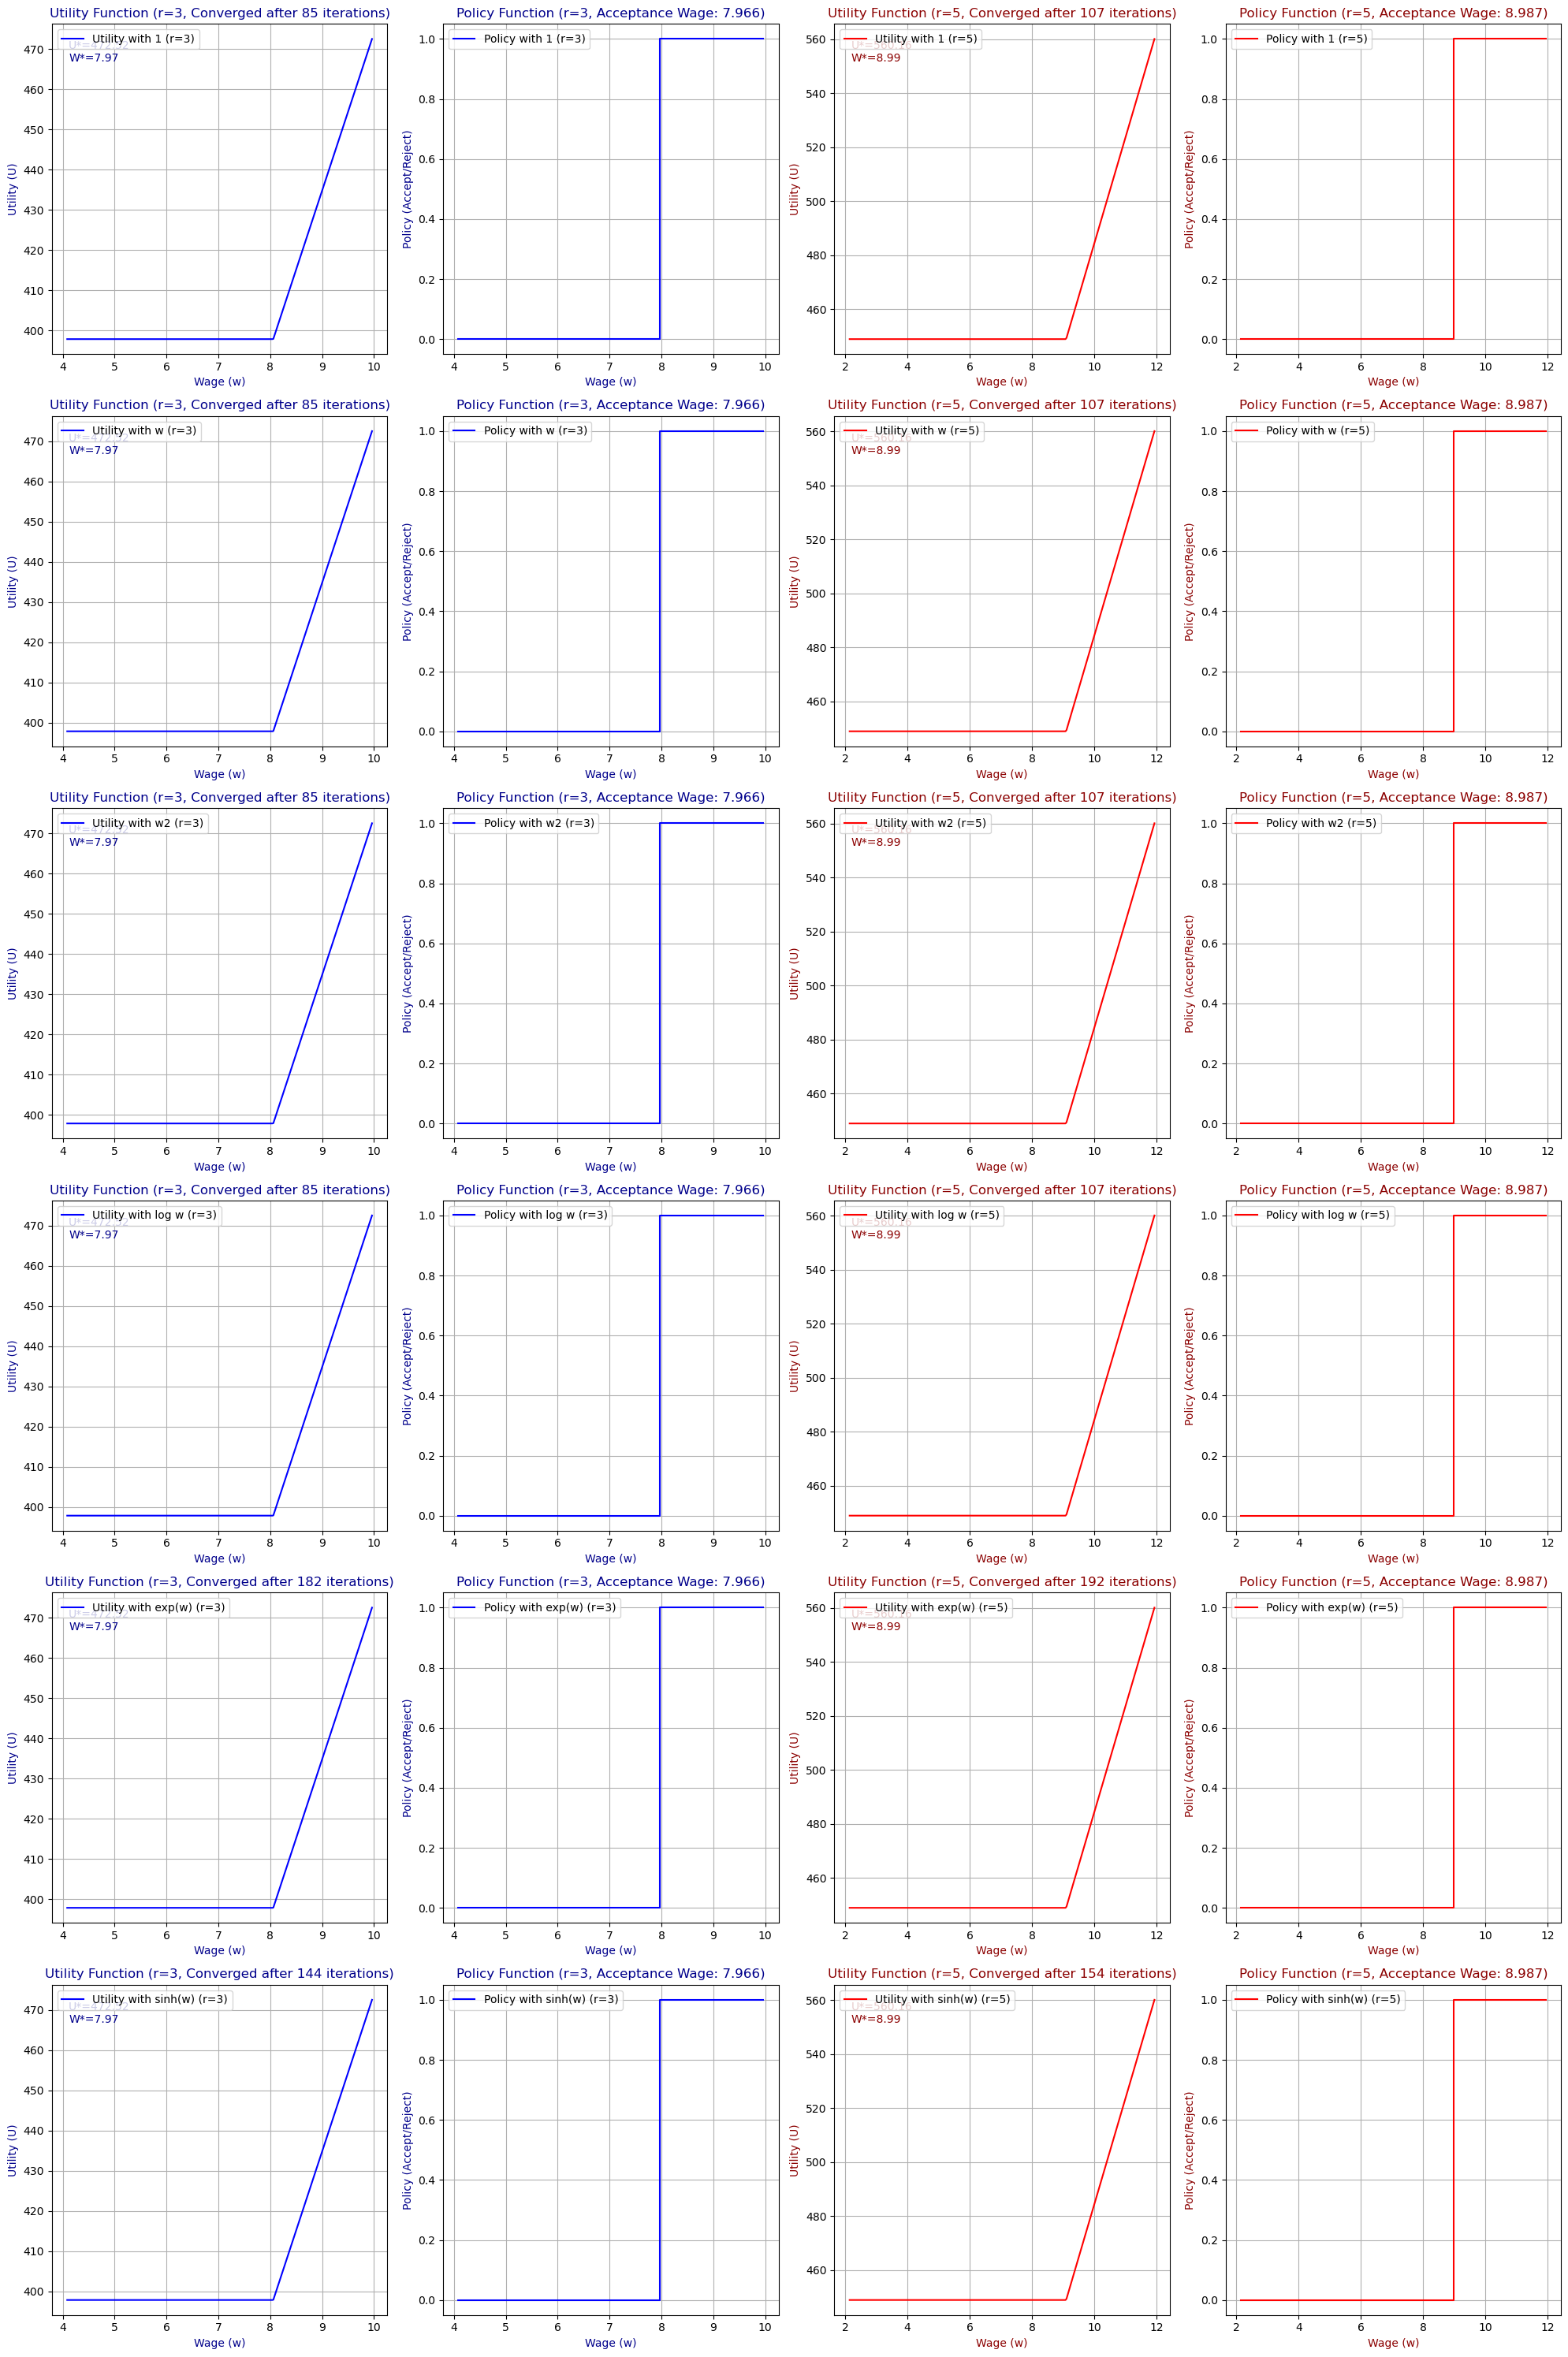

In [10]:
# Initial guesses for the utility function
initial_guesses = {
    '1': np.ones_like(wgrid_r3),
    'w': wgrid_r3,
    'w2': wgrid_r3,
    'log w': np.log(np.maximum(wgrid_r3, 1e-6)),  # Avoid log(0) by using a small positive number
    'exp(w)': np.exp(wgrid_r3),
    'sinh(w)': np.sinh(wgrid_r3)
}

# Create subfigures for each initial guess
fig, axes = plt.subplots(nrows=len(initial_guesses), ncols=4, figsize=(20, 5 * len(initial_guesses)))

# Calculate utility and policy functions for each initial guess for r=3 and r=5
for i, (guess_name, guess_values) in enumerate(initial_guesses.items()):
    # For r=3
    U0_r3, n_iter_r3, eps_r3 = calculate_utility(wgrid_r3, prob_w_r3, p, beta, b, guess_values)
    policy_r3 = ((wgrid_r3 / (1 - beta)) > U0_r3).astype(np.int32)
    acceptance_wage_r3 = wgrid_r3[np.argmax(policy_r3)]

    # For r=5
    U0_r5, n_iter_r5, eps_r5 = calculate_utility(wgrid_r5, prob_w_r5, p, beta, b, guess_values)
    policy_r5 = ((wgrid_r5 / (1 - beta)) > U0_r5).astype(np.int32)
    acceptance_wage_r5 = wgrid_r5[np.argmax(policy_r5)]

    # Plot the utility function for r=3
    axes[i, 0].plot(wgrid_r3, U0_r3, color='blue', label=f'Utility with {guess_name} (r=3)')
    axes[i, 0].set_title(f'Utility Function (r=3, Converged after {n_iter_r3} iterations)', color='darkblue')
    axes[i, 0].set_xlabel('Wage (w)', color='darkblue')
    axes[i, 0].set_ylabel('Utility (U)', color='darkblue')
    axes[i, 0].legend()
    axes[i, 0].grid(True)
    axes[i, 0].text(0.05, 0.95, f'U*={U0_r3.max():.2f}\nW*={acceptance_wage_r3:.2f}', transform=axes[i, 0].transAxes,
                    verticalalignment='top', color='darkblue')

    # Plot the policy function for r=3
    axes[i, 1].step(wgrid_r3, policy_r3, color='blue', where='post', label=f'Policy with {guess_name} (r=3)')
    axes[i, 1].set_title(f'Policy Function (r=3, Acceptance Wage: {acceptance_wage_r3:.3f})', color='darkblue')
    axes[i, 1].set_xlabel('Wage (w)', color='darkblue')
    axes[i, 1].set_ylabel('Policy (Accept/Reject)', color='darkblue')
    axes[i, 1].legend()
    axes[i, 1].grid(True)

    # Plot the utility function for r=5
    axes[i, 2].plot(wgrid_r5, U0_r5, color='red', label=f'Utility with {guess_name} (r=5)')
    axes[i, 2].set_title(f'Utility Function (r=5, Converged after {n_iter_r5} iterations)', color='darkred')
    axes[i, 2].set_xlabel('Wage (w)', color='darkred')
    axes[i, 2].set_ylabel('Utility (U)', color='darkred')
    axes[i, 2].legend()
    axes[i, 2].grid(True)
    axes[i, 2].text(0.05, 0.95, f'U*={U0_r5.max():.2f}\nW*={acceptance_wage_r5:.2f}', transform=axes[i, 2].transAxes,
                    verticalalignment='top', color='darkred')

    # Plot the policy function for r=5
    axes[i, 3].step(wgrid_r5, policy_r5, color='red', where='post', label=f'Policy with {guess_name} (r=5)')
    axes[i, 3].set_title(f'Policy Function (r=5, Acceptance Wage: {acceptance_wage_r5:.3f})', color='darkred')
    axes[i, 3].set_xlabel('Wage (w)', color='darkred')
    axes[i, 3].set_ylabel('Policy (Accept/Reject)', color='darkred')
    axes[i, 3].legend()
    axes[i, 3].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


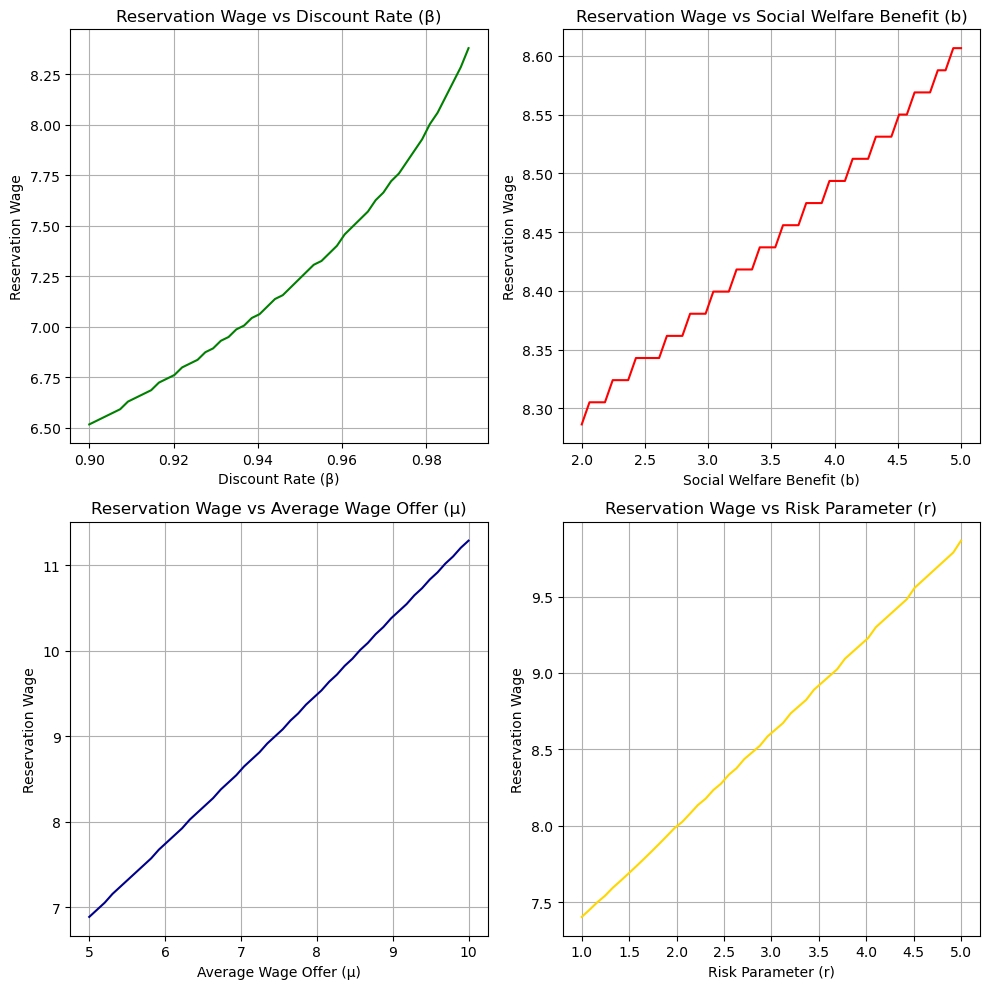

In [11]:
# Function to generate a triangular distribution
def triangular_distribution(mu, r, size=1000, seed=None):
    """
    Generate a triangular distribution.

    Parameters:
    - mu: Mean of the distribution.
    - r: Range parameter; half-width of the distribution.
    - size: Number of samples.
    - seed: Random seed for reproducibility.

    Returns:
    - samples: Array of samples from the triangular distribution.
    """
    np.random.seed(seed)
    return np.random.triangular(mu - r, mu, mu + r, size)

# Function to create a wage distribution
def wage_distribution(samples, grid_size, seed=None):
    """
    Create a wage distribution based on samples.

    Parameters:
    - samples: Array of wage samples.
    - grid_size: Number of grid points for the wage distribution.
    - seed: Random seed for reproducibility.

    Returns:
    - wgrid: Array of wage grid points.
    - prob_w: Array of probabilities for each wage grid point.
    """
    np.random.seed(seed)
    wgrid = np.linspace(np.min(samples), np.max(samples), grid_size)
    prob_w, _ = np.histogram(samples, bins=grid_size, density=True)
    prob_w /= prob_w.sum()
    return wgrid, prob_w

# Function to calculate the utility
def calculate_utility(wgrid, prob_w, p, beta, b, initial_guess, tol=1e-6, max_iter=1e4):
    """
    Calculate the utility function using value iteration.

    Parameters:
    - wgrid: Array of wage grid points.
    - prob_w: Array of probabilities for each wage grid point.
    - p: Probability of receiving an offer.
    - beta: Discount factor.
    - b: Unemployment benefit.
    - initial_guess: Initial guess for the utility values.
    - tol: Tolerance level for convergence.
    - max_iter: Maximum number of iterations.

    Returns:
    - U0: Array of utility values.
    """
    U0 = initial_guess
    n_iter = 0
    eps = tol + 1

    while eps > tol and n_iter < max_iter:
        U1 = b + beta * np.maximum(
            p * (wgrid / (1 - beta)) + (1 - p) * np.dot(prob_w, U0),
            np.dot(prob_w, U0)
        )
        eps = np.max(np.abs(U1 - U0))
        U0 = np.copy(U1)
        n_iter += 1

    return U0

# Parameters
seed_value = 8
r = 3  # Half of the width of the distribution
size = 6666
grid_size = 313
p = 0.8
beta = 0.98
b = 3

# Comparative statics: Discount rate (β)
betas = np.linspace(0.9, 0.99, 50)
reservation_wages_beta = []

for beta in betas:
    dist = triangular_distribution(mu=7, r=r, size=size, seed=seed_value)
    wgrid, prob_w = wage_distribution(dist, grid_size, seed=seed_value)
    initial_guess = np.ones_like(wgrid)
    U0 = calculate_utility(wgrid, prob_w, p, beta, b, initial_guess)
    policy = ((wgrid / (1 - beta)) > U0).astype(np.int32)
    reservation_wage = wgrid[np.argmax(policy)]
    reservation_wages_beta.append(reservation_wage)

# Comparative statics: Social welfare program (b)
bs = np.linspace(2, 5, 50)
reservation_wages_b = []

for b in bs:
    dist = triangular_distribution(mu=7, r=r, size=size, seed=seed_value)
    wgrid, prob_w = wage_distribution(dist, grid_size, seed=seed_value)
    initial_guess = np.ones_like(wgrid)
    U0 = calculate_utility(wgrid, prob_w, p, beta, b, initial_guess)
    policy = ((wgrid / (1 - beta)) > U0).astype(np.int32)
    reservation_wage = wgrid[np.argmax(policy)]
    reservation_wages_b.append(reservation_wage)

# Comparative statics: Increase in average offers (μ)
mus = np.linspace(5, 10, 50)
reservation_wages_mu = []

for mu in mus:
    dist = triangular_distribution(mu, r, size, seed_value)
    wgrid, prob_w = wage_distribution(dist, grid_size, seed_value)
    initial_guess = np.ones_like(wgrid)
    U0 = calculate_utility(wgrid, prob_w, p, beta, b, initial_guess)
    policy = ((wgrid / (1 - beta)) > U0).astype(np.int32)
    reservation_wage = wgrid[np.argmax(policy)]
    reservation_wages_mu.append(reservation_wage)

# Comparative statics: Mean preserving increase in risk (r)
rs = np.linspace(1, 5, 50)
reservation_wages_r = []

for r in rs:
    dist = triangular_distribution(mu=7, r=r, size=size, seed=seed_value)
    wgrid, prob_w = wage_distribution(dist, grid_size, seed=seed_value)
    initial_guess = np.ones_like(wgrid)
    U0 = calculate_utility(wgrid, prob_w, p, beta, b, initial_guess)
    policy = ((wgrid / (1 - beta)) > U0).astype(np.int32)
    reservation_wage = wgrid[np.argmax(policy)]
    reservation_wages_r.append(reservation_wage)

# Create a 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot for Discount Rate (β)
axs[0, 0].plot(betas, reservation_wages_beta, 'green')
axs[0, 0].set_xlabel('Discount Rate (β)')
axs[0, 0].set_ylabel('Reservation Wage')
axs[0, 0].set_title('Reservation Wage vs Discount Rate (β)')
axs[0, 0].grid(True)


# Plot for Social Welfare Benefit (b)
axs[0, 1].plot(bs, reservation_wages_b, 'red')
axs[0, 1].set_xlabel('Social Welfare Benefit (b)')
axs[0, 1].set_ylabel('Reservation Wage')
axs[0, 1].set_title('Reservation Wage vs Social Welfare Benefit (b)')
axs[0, 1].grid(True)

# Plot for Average Wage Offer (μ)
axs[1, 0].plot(mus, reservation_wages_mu, 'darkblue')
axs[1, 0].set_xlabel('Average Wage Offer (μ)')
axs[1, 0].set_ylabel('Reservation Wage')
axs[1, 0].set_title('Reservation Wage vs Average Wage Offer (μ)')
axs[1, 0].grid(True)


# Plot for Risk Parameter (r)
axs[1, 1].plot(rs, reservation_wages_r, 'gold')
axs[1, 1].set_xlabel('Risk Parameter (r)')
axs[1, 1].set_ylabel('Reservation Wage')
axs[1, 1].set_title('Reservation Wage vs Risk Parameter (r)')
axs[1, 1].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()